# Сравнение baseline и модели CNN

В этом ноутбуке приведены: разведочный анализ данных, baseline на логистической регрессии, обучение простой свёрточной нейросети и сравнение результатов по accuracy.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

project_root = Path('..').resolve()
data_dir = project_root / 'data'
artifacts_dir = project_root / 'artifacts'
artifacts_dir.mkdir(parents=True, exist_ok=True)

classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)

print(f'Train size: {len(train_set)}, Test size: {len(test_set)}')

Train size: 60000, Test size: 10000


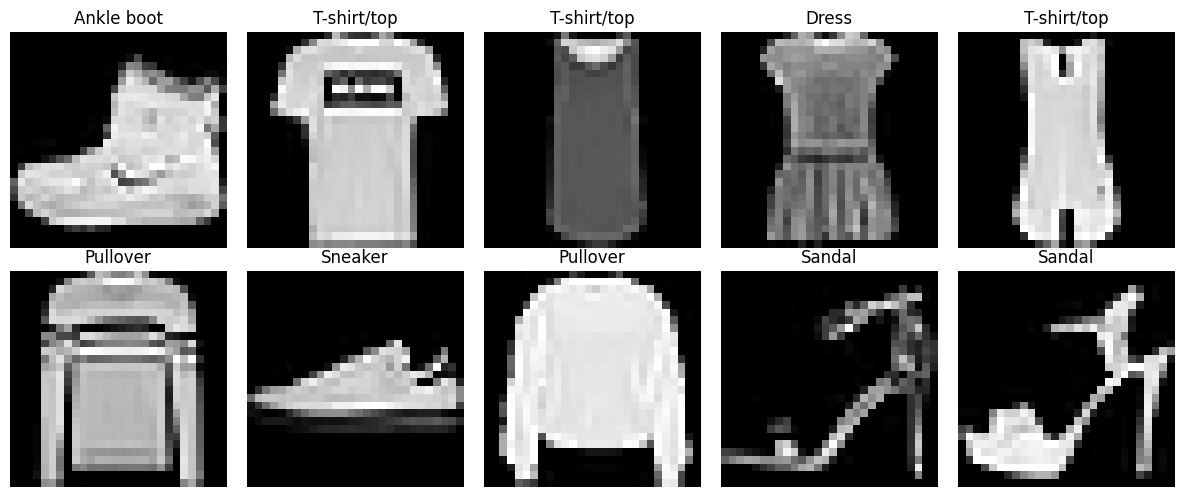

In [2]:
# Визуализация образцов из каждого класса
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, label = train_set[i] # tensor shape [1, 28, 28]
    axes[i // 5, i % 5].imshow(img.squeeze().numpy(), cmap='gray')
    axes[i // 5, i % 5].set_title(classes[label])
    axes[i // 5, i % 5].axis('off')
plt.tight_layout()
plt.show()

C:\Users\Matthew\AppData\Local\Temp\ipykernel_10604\3494757012.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(train_set.targets)


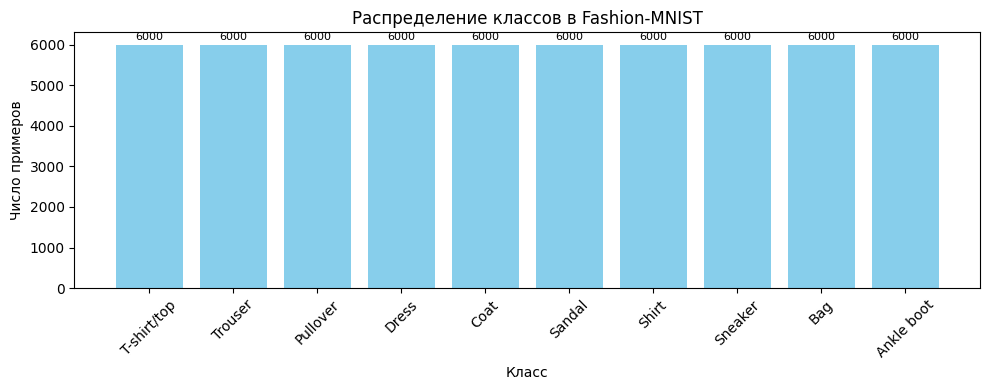

Class balance: min=6000, max=6000, total=60000


In [3]:
labels = np.array(train_set.targets)
counts = np.bincount(labels, minlength=len(classes))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(classes, counts, color='skyblue')
ax.set_title('Распределение классов в Fashion-MNIST')
ax.set_xlabel('Класс')
ax.set_ylabel('Число примеров')
ax.tick_params(axis='x', rotation=45)
for idx, count in enumerate(counts):
    ax.text(idx, count + max(counts) * 0.01, str(count), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Class balance: min={counts.min()}, max={counts.max()}, total={counts.sum()}')

In [ ]:
# Baseline: логистическая регрессия на сплюснутых пикселях
X_train = train_set.data.reshape(-1, 28 * 28).numpy().astype(np.float32) / 255.0
y_train = train_set.targets.numpy()
X_test = test_set.data.reshape(-1, 28 * 28).numpy().astype(np.float32) / 255.0
y_test = test_set.targets.numpy()

baseline = LogisticRegression(max_iter=1000, solver='saga', verbose=0)
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_preds)
print(f'Baseline LogisticRegression accuracy: {baseline_acc:.4f}')

In [ ]:
# Подготовка CNN и обучающего цикла
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cpu')
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=0)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 3
history = {'train_loss': [], 'train_acc': []}

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    history['train_loss'].append(epoch_loss / total)
    history['train_acc'].append(correct / total)
    print(f'Epoch {epoch}/{epochs}: loss={epoch_loss / total:.4f}, acc={correct / total:.4f}')

In [ ]:
# Оценка CNN на тестовой выборке
model.eval()
correct = 0
total = 0
all_preds = []
all_targets = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(labels.numpy())
        correct += (preds == labels.numpy()).sum()
        total += labels.size(0)
cnn_acc = correct / total
print(f'CNN accuracy on test set: {cnn_acc:.4f}')

cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix for SimpleCNN')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Сохранение модели и метрик
torch.save(model.state_dict(), artifacts_dir / 'model.pt')
metrics = {
    'dataset': 'Fashion-MNIST',
    'baseline': {
        'model': 'LogisticRegression',
        'accuracy': float(baseline_acc),
        'description': 'Logistic regression on flattened 28x28 images'
    },
    'final_model': {
        'name': 'SimpleCNN',
        'accuracy': float(cnn_acc),
        'description': 'CNN trained on Fashion-MNIST with 3 epochs'
    },
}
with open(artifacts_dir / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print('Saved model and metrics to artifacts/')